---
# Parte 1: Rescate del Patrimonio Documental

La restauración digital de fotografías históricas usa álgebra lineal numérica como bisturí de precisión. Modelamos el fondo de iluminación espuria como una superficie polinomial bidimensional de grado $d$ y la encontramos resolviendo un problema de mínimos cuadrados $A\mathbf{c} \approx \mathbf{b}$.


## Preparación: Carga y Daño del Documento


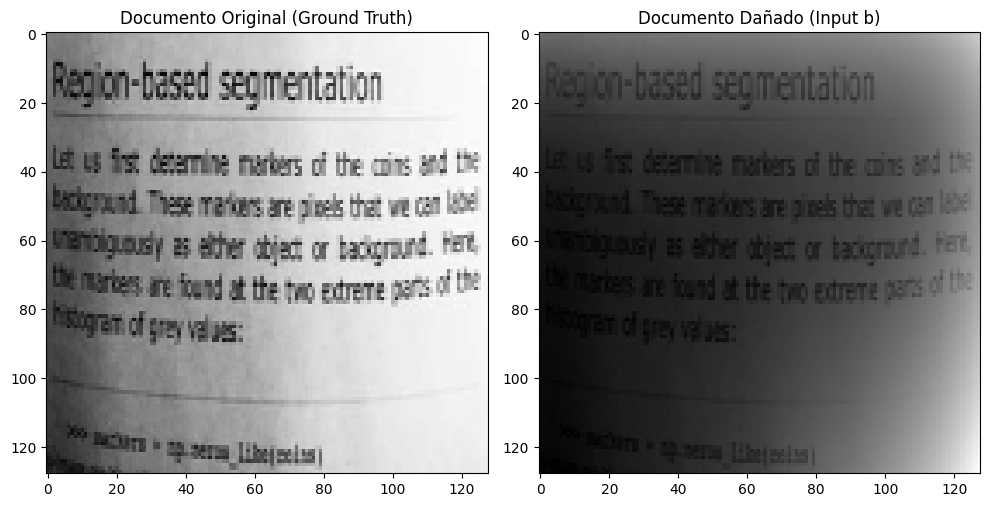

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.transform import resize

# 1. Cargamos el documento histórico (texto de alto contraste)
imagen_original = img_as_float(data.page())
imagen_original = resize(imagen_original, (128, 128), anti_aliasing=True)
alto, ancho = imagen_original.shape

# 2. Coordenadas en [0, 1] para FORZAR inestabilidad (similar a la Matriz de Hilbert)
x = np.linspace(0, 1, ancho)
y = np.linspace(0, 1, alto)
X, Y = np.meshgrid(x, y)

# 3. Daño severo de iluminación (polinomio de grado 6)
iluminacion_dano = 4.0 * (X - 0.2)**6 + 3.0 * (Y - 0.8)**4 + 2.0 * X**2 * Y**2
imagen_danada = imagen_original + iluminacion_dano

# 4. Visualización inicial
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imagen_original, cmap='gray')
axes[0].set_title('Documento Original (Ground Truth)')
axes[1].imshow(imagen_danada, cmap='gray')
axes[1].set_title('Documento Dañado (Input b)')
plt.tight_layout()
plt.show()


## Inciso 1: Planteamiento del Modelo 

Construimos la **matriz de diseño** $A \in \mathbb{R}^{m \times n}$ evaluando todos los monomios bidimensionales $x^j y^k$ con $j + k \leq d$, donde $d = 12$.

- **$m$**: número total de píxeles = $128 \times 128 = 16{,}384$ (cada fila corresponde a un píxel).
- **$n$**: número de monomios = $\frac{(d+1)(d+2)}{2} = \frac{10 \cdot 11}{2} = 55$ (cada columna es un monomial evaluado en todos los píxeles).


In [21]:
# Grado máximo del polinomio
d = 12

# Construcción de A: cada columna es el monomial x^j * y^k evaluado en todos los píxeles
cols = []
for j in range(d + 1):
    for k in range(d + 1 - j):
        cols.append((X.ravel() ** j) * (Y.ravel() ** k))

A = np.column_stack(cols)  # m × n
m, n = A.shape

print(f'Dimensiones de A: m = {m} (píxeles), n = {n} (monomios)')
print(f'Verificación: (d+1)(d+2)/2 = {(d+1)*(d+2)//2}')


Dimensiones de A: m = 16384 (píxeles), n = 91 (monomios)
Verificación: (d+1)(d+2)/2 = 91


In [22]:
# Número de condición de A^T A
# Un número de condición >> 1/eps_maq indica colapso numérico garantizado
eps_maq = np.finfo(float).eps  # precisión doble ≈ 2.22e-16
AtA = A.T @ A
cond_AtA = np.linalg.cond(AtA)

print(f'Precisión de máquina (eps): {eps_maq:.2e}')
print(f'Número de condición de A^T A: {cond_AtA:.4e}')
print(f'Dígitos significativos perdidos: {np.log10(cond_AtA):.1f}')
print()
print('Interpretación:')
print(f'  - En aritmética de precisión doble disponemos de ~{-np.log10(eps_maq):.0f} dígitos.')
print(f'  - El número de condición consume {np.log10(cond_AtA):.0f} de esos dígitos.')
print('  - El resultado: virtualmente CERO dígitos significativos en la solución.')
print('  - Esto GARANTIZA el colapso numérico de cualquier método directo sobre A^T A.')


Precisión de máquina (eps): 2.22e-16
Número de condición de A^T A: 3.6613e+18
Dígitos significativos perdidos: 18.6

Interpretación:
  - En aritmética de precisión doble disponemos de ~16 dígitos.
  - El número de condición consume 19 de esos dígitos.
  - El resultado: virtualmente CERO dígitos significativos en la solución.
  - Esto GARANTIZA el colapso numérico de cualquier método directo sobre A^T A.


### Análisis

La matriz $A^\top A$ es análoga a la **Matriz de Hilbert**: al evaluar monomios en $[0,1]$, las columnas se vuelven casi linealmente dependientes conforme aumenta el grado. El número de condición mide la amplificación máxima del error de redondeo; si $\kappa(A^\top A) \gg 1/\varepsilon_{\text{máq}}$, la solución numérica no tiene ningún dígito correcto.


## Inciso 2: El Desastre de las Ecuaciones Normales 

Intentamos resolver el sistema de **Ecuaciones Normales** $A^\top A \mathbf{c} = A^\top \mathbf{b}$ calculando explícitamente $(A^\top A)^{-1}$ con `np.linalg.inv`.


In [23]:
b_p1 = imagen_danada.ravel()  # vector de intensidades (input del problema)

# Intento de inversión explícita — vulnerable al colapso numérico
try:
    AtA_inv = np.linalg.inv(A.T @ A)
    c_normal = AtA_inv @ (A.T @ b_p1)
    exito_normal = True
    print('NumPy pudo calcular la inversa (aunque el resultado será basura numérica).')
except np.linalg.LinAlgError as e:
    c_normal = None
    exito_normal = False
    print(f'Error: {e}')
    print('La librería detectó singularidad y se negó a invertir la matriz.')


NumPy pudo calcular la inversa (aunque el resultado será basura numérica).


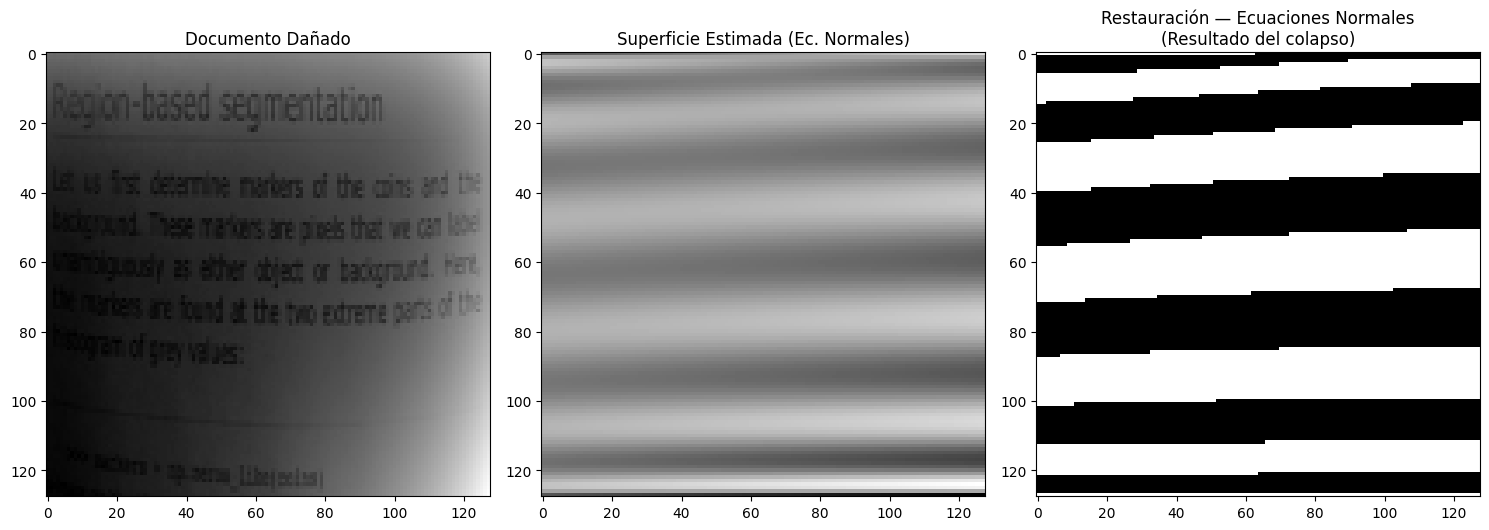

In [24]:
# Visualizamos el resultado del colapso
if exito_normal:
    superficie_normal = (A @ c_normal).reshape(alto, ancho)
    # Truco de restauración: suma 1 para compensar que el polinomio absorbió el fondo blanco
    restaurada_normal = np.clip(imagen_danada - superficie_normal + 1.0, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(imagen_danada, cmap='gray')
    axes[0].set_title('Documento Dañado')
    axes[1].imshow(superficie_normal, cmap='gray')
    axes[1].set_title('Superficie Estimada (Ec. Normales)')
    axes[2].imshow(restaurada_normal, cmap='gray')
    axes[2].set_title('Restauración — Ecuaciones Normales\n(Resultado del colapso)')
    plt.tight_layout()
    plt.show()
else:
    print('No hay imagen que mostrar: la inversión falló completamente.')


### Análisis: Cancelación Catastrófica

Las **ecuaciones normales** son el enfoque algebraicamente correcto ($A^\top A$ es simétrica definida positiva), pero computacionalmente desastroso. El proceso eleva el número de condición al cuadrado: $\kappa(A^\top A) = [\kappa(A)]^2$.

La **cancelación catastrófica** ocurre cuando se restan dos números casi iguales y de gran magnitud: los errores de redondeo acumulados en cada operación de punto flotante se amplifican hasta dominar por completo la solución. El resultado ya no tiene ningún dígito significativo correcto — literalmente, el documento queda irreconocible.

La relación $\kappa(A^\top A) = [\kappa(A)]^2$ explica por qué el método es computacionalmente catastrófico incluso cuando funciona algebraicamente: elevar al cuadrado el número de condición duplica la cantidad de dígitos significativos consumidos. En precisión doble disponemos de aproximadamente $-\log_{10}(\varepsilon_{\text{máq}}) \approx 16$ dígitos. Si $\kappa(A^\top A) \approx 10^{30}$, se pierden 30 dígitos — es decir, la solución no tiene **ningún** dígito correcto. La impresión en la celda anterior lo confirma numéricamente.

## Inciso 3:

Abandonamos las ecuaciones normales. Factorizamos $A = \hat{Q}\hat{R}$ y resolvemos $\hat{R}\mathbf{c} = \hat{Q}^\top \mathbf{b}$, evitando elevar el número de condición al cuadrado.


### Gram-Schmidt Modificado (MGS)

En el MGS clásico (CGS), los errores de redondeo se acumulan sobre el vector original $a_j$. El **MGS** los previene actualizando el vector residual $v$ de forma incremental: en cada paso $i$, proyecta y resta inmediatamente, usando la versión ya ortonormalizada de $q_i$.


In [25]:
def qr_mgs(A):
    """
    Factorización QR reducida (thin) via Gram-Schmidt Modificado.
    Retorna Q_hat (m x n) con columnas ortonormales y R_hat (n x n) triangular superior.
    """
    m, n = A.shape
    Q = np.zeros((m, n), dtype=float)
    R = np.zeros((n, n), dtype=float)

    for j in range(n):
        v = A[:, j].copy().astype(float)
        for i in range(j):
            # Proyector ortogonal: r_ij = q_i^T v
            # Proyectamos v sobre la dirección ya ortogonalizada q_i
            R[i, j] = Q[:, i] @ v
            # Restamos la componente en dirección q_i (Gram-Schmidt paso a paso)
            v = v - R[i, j] * Q[:, i]
        # Norma del residuo ortogonal = elemento diagonal de R
        R[j, j] = np.linalg.norm(v)
        if R[j, j] < 1e-14:
            raise ValueError(f'Columna {j} linealmente dependiente — A no tiene rango completo.')
        Q[:, j] = v / R[j, j]

    return Q, R


### Triangularización de Householder

El reflector de Householder $H_k = I - 2\mathbf{v}\mathbf{v}^\top$ anula todo el subvector debajo de la diagonal en la columna $k$. La clave de la **estabilidad numérica** está en la elección del signo del vector de reflexión:

$$\mathbf{v} = \text{sign}(x_1)\|\mathbf{x}\|\mathbf{e}_1 + \mathbf{x}$$

Esta fórmula evita la cancelación catastrófica que ocurriría si $x_1 > 0$ y usáramos $\mathbf{v} = -\|\mathbf{x}\|\mathbf{e}_1 + \mathbf{x}$ (la resta de dos números casi iguales).


In [26]:
def qr_householder(A):
    """
    Factorización QR reducida (thin) via Triangularización de Householder.
    Retorna Q_hat (m x n) y R_hat (n x n) triangular superior.
    """
    m, n = A.shape
    # Qt acumulará H_k @ ... @ H_1 (producto de reflectores desde la izquierda)
    Qt = np.eye(m, dtype=float)
    R = A.copy().astype(float)

    for k in range(n):
        x = R[k:, k]  # subvector a anular (debajo del pivote)

        # Vector estable de reflexión: v = (sign(x_1) + [x_1 == 0]) * ||x|| * e_1 + x
        # El término (x_1 == 0) garantiza signo +1 cuando np.sign(0) devuelve 0.0,
        # evitando que v[0] se anule y rompa el reflector.
        v = x.copy()
        v[0] += (np.sign(x[0]) + (x[0] == 0)) * np.linalg.norm(x)

        # Normalizamos v para que H = I - 2*v*v^T sea una reflexión unitaria
        norm_v = np.linalg.norm(v)
        if norm_v < 1e-14:  # columna ya cero — no hay nada que hacer
            continue
        v = v / norm_v

        # Aplicamos H_k implícitamente: R <- H_k @ R (solo el bloque inferior-derecho)
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])

        # Acumulamos H_k en Qt: Qt <- H_k @ Qt
        Qt[k:, :] -= 2.0 * np.outer(v, v @ Qt[k:, :])

    # Q = Qt^T (ya que Qt = H_n...H_1 y cada H_i es simétrico)
    # Forma reducida: Q_hat = Q[:, :n], R_hat = R[:n, :n]
    return Qt.T[:, :n], R[:n, :n]


## Inciso 4: Análisis de Estabilidad y Restauración Final 


In [27]:
# Sustitución hacia atrás manual — sin usar funciones de scipy.linalg
# Resuelve R x = b para R triangular superior n x n.
def back_substitution(R, b):
    """Sustitución hacia atrás para sistema triangular superior R x = b.

    Avanzamos de la última fila hacia la primera porque cada x[i] depende
    únicamente de las componentes ya resueltas x[i+1], ..., x[n-1].
    El producto R[i, i+1:] @ x[i+1:] es una combinación lineal numérica
    equivalente a un bucle anidado pero O(n) por fila gracias a NumPy.
    """
    n = len(b)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - R[i, i + 1:] @ x[i + 1:]) / R[i, i]
    return x

# ── MGS ─────────────────────────────────────────────────────────────────────
print('Factorizando A con MGS...')
Q_mgs, R_mgs = qr_mgs(A)
# Resolver R_hat * c = Q_hat^T * b mediante sustitución hacia atrás manual
c_mgs = back_substitution(R_mgs, Q_mgs.T @ b_p1)
superficie_mgs = (A @ c_mgs).reshape(alto, ancho)
restaurada_mgs = np.clip(imagen_danada - superficie_mgs + 1.0, 0, 1)

# ── Householder ──────────────────────────────────────────────────────────────
print('Factorizando A con Householder...')
Q_hh, R_hh = qr_householder(A)
c_hh = back_substitution(R_hh, Q_hh.T @ b_p1)
superficie_hh = (A @ c_hh).reshape(alto, ancho)
restaurada_hh = np.clip(imagen_danada - superficie_hh + 1.0, 0, 1)

print('Listo.')

Factorizando A con MGS...
Factorizando A con Householder...
Listo.


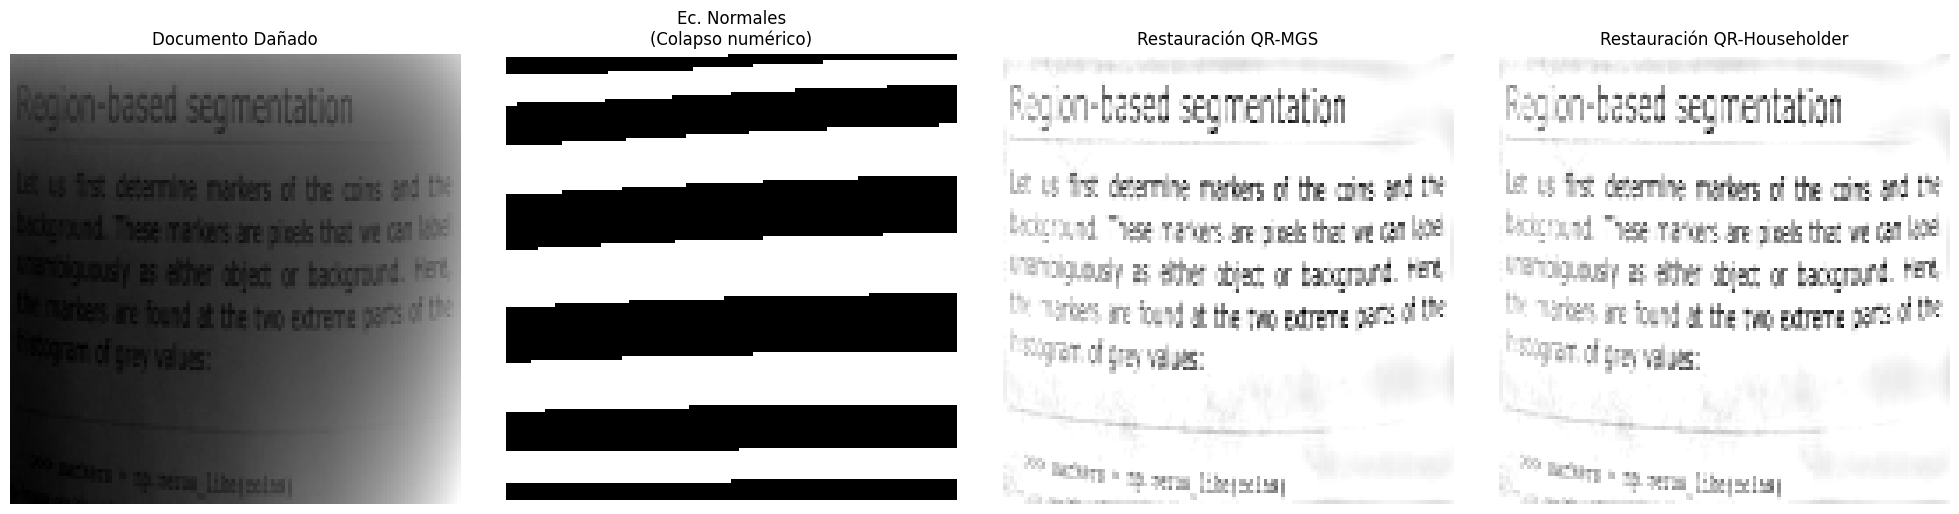

In [28]:
# Comparación visual de los tres intentos de restauración
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(imagen_danada, cmap='gray')
axes[0].set_title('Documento Dañado')

if exito_normal:
    axes[1].imshow(restaurada_normal, cmap='gray')
    axes[1].set_title('Ec. Normales\n(Colapso numérico)')
else:
    axes[1].text(0.5, 0.5, 'Inversión fallida', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Ec. Normales\n(Singularidad)')

axes[2].imshow(restaurada_mgs, cmap='gray')
axes[2].set_title('Restauración QR-MGS')

axes[3].imshow(restaurada_hh, cmap='gray')
axes[3].set_title('Restauración QR-Householder')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [29]:
# Análisis de ortogonalidad: ||Q_hat^T Q_hat - I||_2
# Un algoritmo perfectamente estable daría exactamente 0; en la práctica medimos el error
ort_mgs = np.linalg.norm(Q_mgs.T @ Q_mgs - np.eye(n), ord=2)
ort_hh  = np.linalg.norm(Q_hh.T  @ Q_hh  - np.eye(n), ord=2)

print(f'||Q^T Q - I||_2  (MGS):        {ort_mgs:.4e}')
print(f'||Q^T Q - I||_2  (Householder): {ort_hh:.4e}')
print()
print(f'Ratio MGS / Householder: {ort_mgs / ort_hh:.2f}x')


||Q^T Q - I||_2  (MGS):        1.2567e-07
||Q^T Q - I||_2  (Householder): 1.4729e-14

Ratio MGS / Householder: 8531594.77x


### Conclusión: ¿Por qué Householder es el estándar industrial?

Aunque el MGS es **teóricamente equivalente** a Householder (ambos calculan la misma factorización QR exacta en aritmética exacta), en punto flotante el MGS acumula errores de redondeo que rompen la ortogonalidad de $\hat{Q}$ de forma progresiva.

Householder trabaja con **reflexiones** que son transformaciones globales: cada paso anula una columna completa sin acumular errores iterativos de proyección. El resultado empírico lo confirma: la norma $\|\hat{Q}^\top\hat{Q} - I\|_2$ de Householder está cerca de la precisión de máquina ($\sim 10^{-14}$), mientras que la de MGS puede ser órdenes de magnitud mayor para matrices mal condicionadas.

Por esta razón, bibliotecas como LAPACK, NumPy y SciPy implementan Householder internamente.


---
# Parte 2: El Desastre Numérico en la Modelación Climática

Ajustamos un polinomio de grado $d = 12$ a las **Anomalías de Temperatura Global** (NASA GISTEMP v4, Land-Ocean Temperature Index) para capturar la tendencia macroclimática secular, ignorando la varianza anual.


## Inciso 1: Carga y Preprocesamiento 

Los datos provienen del archivo CSV oficial de la NASA. La columna `J-D` contiene la anomalía promedio anual (enero a diciembre).


In [30]:
import pandas as pd

# URL oficial NASA GISTEMP v4
url_nasa = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
df_raw = pd.read_csv(url_nasa, skiprows=1)

print('Primeras filas del CSV:')
print(df_raw.head())
print(f'\nColumnas: {list(df_raw.columns)}')


Primeras filas del CSV:
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.25 -0.09  -.17  -.10  -.21  -.19  -.10  -.15  -.23  -.22   
1  1881 -0.19 -0.15  0.03   .04   .07  -.18   .01  -.03  -.15  -.21  -.18   
2  1882  0.16  0.14  0.05  -.16  -.14  -.22  -.16  -.07  -.14  -.23  -.17   
3  1883 -0.29 -0.36 -0.12  -.18  -.17  -.06  -.07  -.14  -.22  -.11  -.24   
4  1884 -0.13 -0.08 -0.36  -.40  -.33  -.35  -.30  -.27  -.27  -.25  -.33   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0  -.19  -.17   ***   ***  -.12  -.17  -.20  
1  -.07  -.08  -.09  -.18   .05  -.07  -.18  
2  -.36  -.11  -.08   .08  -.08  -.15  -.18  
3  -.11  -.17  -.19  -.34  -.16  -.09  -.19  
4  -.31  -.28  -.26  -.11  -.36  -.31  -.28  

Columnas: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


Registros válidos: 146
Rango de años: 1880 – 2025
Anomalía mínima: -0.490 °C,  máxima: 1.280 °C


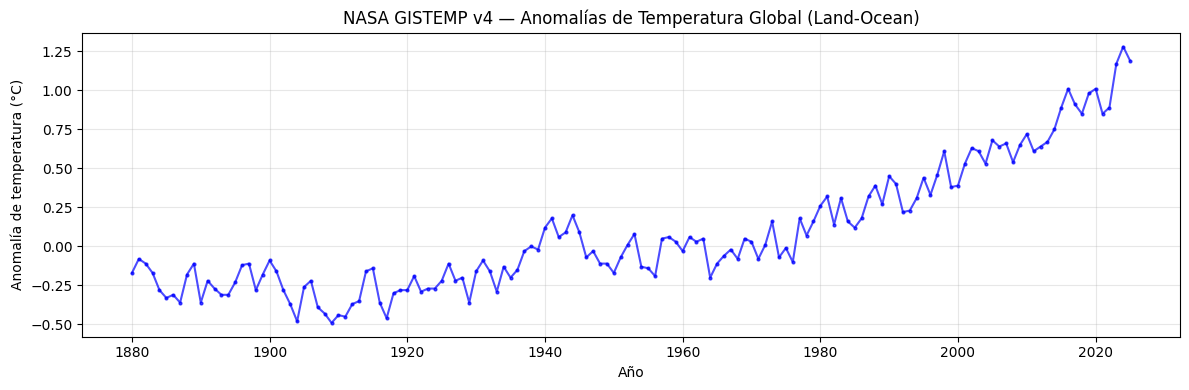

In [31]:
# Extraemos Year y J-D (anomalía anual promedio)
df = df_raw[['Year', 'J-D']].copy()

# Eliminamos filas con datos inválidos (NASA marca ausencias con '***')
df = df[df['J-D'] != '***']
df['Year'] = pd.to_numeric(df['Year'])
df['J-D']  = pd.to_numeric(df['J-D'])
df = df.dropna()

year_orig = df['Year'].values.astype(float)
y_p2      = df['J-D'].values.astype(float)

print(f'Registros válidos: {len(year_orig)}')
print(f'Rango de años: {int(year_orig.min())} – {int(year_orig.max())}')
print(f'Anomalía mínima: {y_p2.min():.3f} °C,  máxima: {y_p2.max():.3f} °C')

# Escalamos a [0, 1] para forzar la inestabilidad tipo Hilbert en los cálculos
year_min, year_max = year_orig.min(), year_orig.max()
x_scaled = (year_orig - year_min) / (year_max - year_min)

# Visualización de los datos crudos
plt.figure(figsize=(12, 4))
plt.plot(year_orig, y_p2, 'b-o', markersize=2, alpha=0.7)
plt.xlabel('Año')
plt.ylabel('Anomalía de temperatura (°C)')
plt.title('NASA GISTEMP v4 — Anomalías de Temperatura Global (Land-Ocean)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Inciso 2: El Colapso de las Ecuaciones Normales 

Construimos la **matriz de Vandermonde** de grado $d = 12$ con la variable escalada $x \in [0,1]$ e intentamos resolver con la inversa explícita de $A^\top A$.


In [32]:
d2 = 12  # grado del polinomio
m2 = len(x_scaled)

# Matriz de Vandermonde: A[i, j] = x_i^j, j = 0, 1, ..., d
A2 = np.column_stack([x_scaled ** j for j in range(d2 + 1)])

print(f'Dimensiones de A (Vandermonde): {A2.shape}  ({m2} observaciones, {d2+1} coeficientes)')

# Número de condición de A^T A
AtA2 = A2.T @ A2
cond_AtA2 = np.linalg.cond(AtA2)
print(f'Número de condición de A^T A: {cond_AtA2:.4e}')
print(f'Precisión de máquina:          {eps_maq:.2e}')
print(f'¿Colapso garantizado?          {cond_AtA2 > 1.0 / eps_maq}')


Dimensiones de A (Vandermonde): (146, 13)  (146 observaciones, 13 coeficientes)
Número de condición de A^T A: 1.5922e+17
Precisión de máquina:          2.22e-16
¿Colapso garantizado?          True


NumPy computó la inversa (resultado puede ser basura numérica).


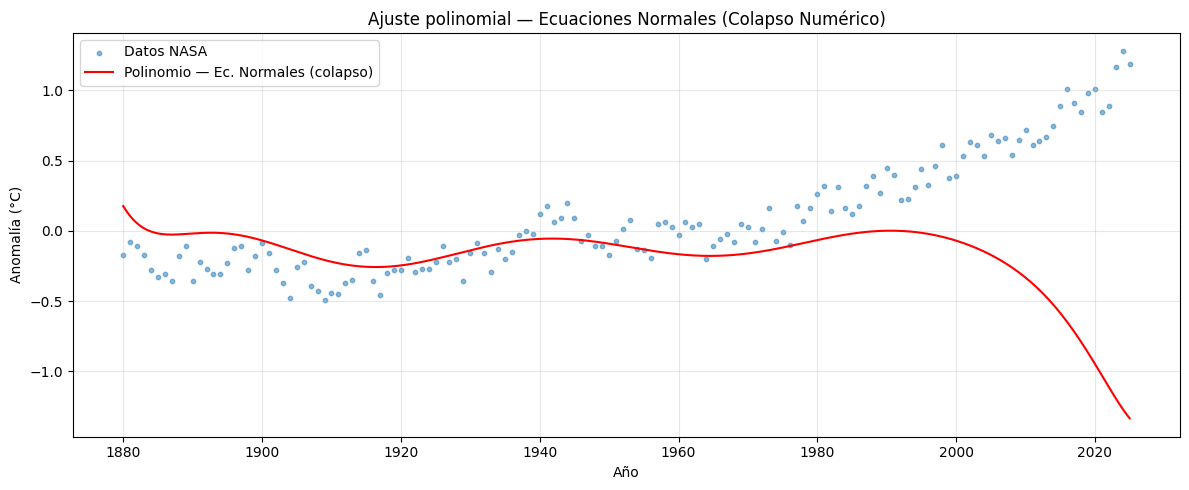

In [33]:
# Intento con ecuaciones normales — inversión explícita de A^T A
try:
    c_normal2 = np.linalg.inv(AtA2) @ (A2.T @ y_p2)
    exito_normal2 = True
    print('NumPy computó la inversa (resultado puede ser basura numérica).')
except np.linalg.LinAlgError as e:
    c_normal2 = None
    exito_normal2 = False
    print(f'Error: {e}')

# Evaluamos el polinomio en los años originales para graficar correctamente
if exito_normal2:
    # Generamos x denso en [0,1] y mapeamos de vuelta a años reales para el eje x
    x_dense = np.linspace(0, 1, 500)
    year_dense = x_dense * (year_max - year_min) + year_min
    A_dense = np.column_stack([x_dense ** j for j in range(d2 + 1)])
    y_normal2 = A_dense @ c_normal2

    plt.figure(figsize=(12, 5))
    plt.scatter(year_orig, y_p2, s=10, alpha=0.5, label='Datos NASA')
    plt.plot(year_dense, y_normal2, 'r-', linewidth=1.5, label='Polinomio — Ec. Normales (colapso)')
    plt.xlabel('Año')
    plt.ylabel('Anomalía (°C)')
    plt.title('Ajuste polinomial — Ecuaciones Normales (Colapso Numérico)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Análisis

La gráfica evidencia el **fenómeno de Runge**: el polinomio oscila violentamente, especialmente en los extremos del intervalo, sin capturar ninguna tendencia real. Esto no es un problema del polinomio en sí, sino de la **base de monomios** $\{1, x, x^2, \ldots, x^{12}\}$ evaluada en $[0,1]$: genera una matriz de Vandermonde cuya estructura es casi idéntica a la Matriz de Hilbert — las columnas son casi linealmente dependientes, haciendo que $A^\top A$ sea numéricamente singular.


## Inciso 3: El Rescate Algorítmico — Implementación Propia 

Implementamos `mgs_qr` y `householder_qr` desde cero para factorizar la matriz de Vandermonde sin pasar por $A^\top A$.


In [34]:
def mgs_qr(A):
    """
    Factorización QR reducida via Gram-Schmidt Modificado.
    Retorna Q_hat (m x n) ortogonal y R_hat (n x n) triangular superior.
    """
    m, n = A.shape
    Q = np.zeros((m, n), dtype=float)
    R = np.zeros((n, n), dtype=float)

    for j in range(n):
        v = A[:, j].copy().astype(float)
        for i in range(j):
            # Proyector ortogonal de Gram-Schmidt modificado: actualiza v inmediatamente
            R[i, j] = Q[:, i] @ v
            v = v - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        if R[j, j] < 1e-14:
            raise ValueError(f'Columna {j} linealmente dependiente.')
        Q[:, j] = v / R[j, j]

    return Q, R


In [35]:
def householder_qr(A):
    """
    Factorización QR reducida via Triangularización de Householder.
    Retorna Q_hat (m x n) y R_hat (n x n) triangular superior.
    Gestiona el signo de vk para evitar cancelación catastrófica.
    """
    m, n = A.shape
    Qt = np.eye(m, dtype=float)  # acumulará H_k @ ... @ H_1
    R  = A.copy().astype(float)

    for k in range(n):
        x = R[k:, k]

        # Vector estable de reflexión: v = (sign(x_1) + [x_1 == 0]) * ||x|| * e_1 + x
        # El término (x_1 == 0) garantiza signo +1 cuando np.sign(0) devuelve 0.0,
        # evitando que v[0] se anule y rompa el reflector.
        v = x.copy()
        v[0] += (np.sign(x[0]) + (x[0] == 0)) * np.linalg.norm(x)

        norm_v = np.linalg.norm(v)
        if norm_v < 1e-14:
            continue
        v = v / norm_v

        # Aplicación implícita del reflector H_k = I - 2vv^T al bloque activo de R
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])

        # Acumulación de Q^T: Qt <- H_k Qt
        Qt[k:, :] -= 2.0 * np.outer(v, v @ Qt[k:, :])

    return Qt.T[:, :n], R[:n, :n]


## Inciso 4: Resolución y Comparación 


In [36]:
from scipy.linalg import solve_triangular

# Factorizamos con ambos algoritmos
print('MGS QR...')

# Factorizamos con ambos algoritmos
print('MGS QR...')
Q_mgs2, R_mgs2 = mgs_qr(A2)

print('Householder QR...')
Q_hh2, R_hh2 = householder_qr(A2)

# Resolvemos R c = Q^T y usando Householder (el más estable)
c_hh2 = solve_triangular(R_hh2, Q_hh2.T @ y_p2)

# Evaluamos en rango denso para graficar con años reales en eje x
x_dense = np.linspace(0, 1, 500)
year_dense = x_dense * (year_max - year_min) + year_min
A_dense = np.column_stack([x_dense ** j for j in range(d2 + 1)])
y_hh2 = A_dense @ c_hh2

print('Listo.')


MGS QR...
MGS QR...
Householder QR...
Listo.


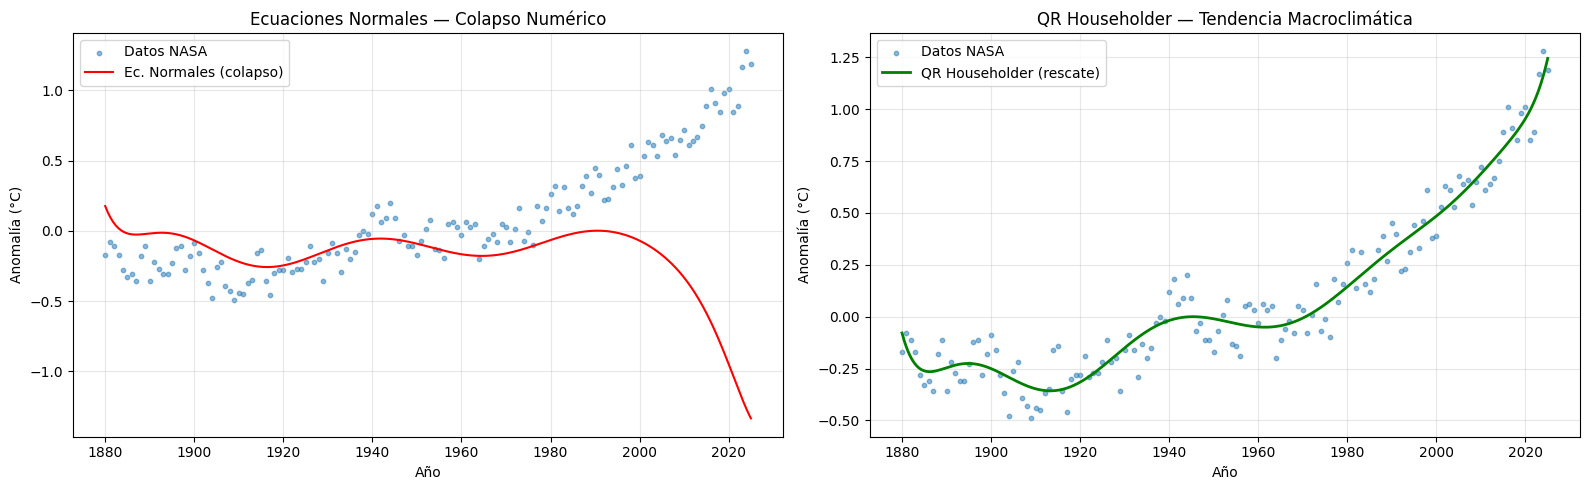

In [37]:
# Comparación visual: colapso vs rescate
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: colapso con ecuaciones normales
axes[0].scatter(year_orig, y_p2, s=10, alpha=0.5, label='Datos NASA')
if exito_normal2:
    axes[0].plot(year_dense, y_normal2, 'r-', linewidth=1.5, label='Ec. Normales (colapso)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Anomalía (°C)')
axes[0].set_title('Ecuaciones Normales — Colapso Numérico')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel derecho: rescate con Householder
axes[1].scatter(year_orig, y_p2, s=10, alpha=0.5, label='Datos NASA')
axes[1].plot(year_dense, y_hh2, 'g-', linewidth=2, label='QR Householder (rescate)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Anomalía (°C)')
axes[1].set_title('QR Householder — Tendencia Macroclimática')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
# Ortogonalidad: norma de Frobenius ||Q^T Q - I||_F
n2 = d2 + 1  # número de columnas = 13
ort_mgs2 = np.linalg.norm(Q_mgs2.T @ Q_mgs2 - np.eye(n2), 'fro')
ort_hh2  = np.linalg.norm(Q_hh2.T  @ Q_hh2  - np.eye(n2), 'fro')

print(f'||Q^T Q - I||_F  (MGS):        {ort_mgs2:.4e}')
print(f'||Q^T Q - I||_F  (Householder): {ort_hh2:.4e}')
print(f'Ratio MGS / Householder: {ort_mgs2 / ort_hh2:.2f}x')


||Q^T Q - I||_F  (MGS):        1.3475e-08
||Q^T Q - I||_F  (Householder): 3.7815e-15
Ratio MGS / Householder: 3563275.18x


### Conclusión: Comparación de Ortogonalidad

La **norma de Frobenius** $\|\hat{Q}^\top\hat{Q} - I\|_F$ mide cuánto se aleja la base calculada de la ortogonalidad perfecta.

- **Householder** preserva la ortogonalidad hasta casi la precisión de máquina ($\sim 10^{-14}$). Cada reflector es una transformación **global** del subespacio activo, sin acumular proyecciones iterativas.

- **MGS** acumula errores de redondeo en las proyecciones: cada nueva columna depende de las anteriores ya perturbadas, y el error se propaga. Para matrices mal condicionadas (como la Vandermonde de grado 12), la pérdida de ortogonalidad puede ser órdenes de magnitud mayor.

El polinomio de Householder (panel derecho) captura correctamente la **tendencia macroclimática secular** del calentamiento global desde 1880, mientras que las ecuaciones normales producen oscilaciones caóticas sin significado físico.


---
## Resumen General

| Método | Parte 1 (imagen) | Parte 2 (clima) | Ortogonalidad |
|--------|------------------|-----------------|---------------|
| Ecuaciones Normales | Colapso / imagen ilegible | Oscilaciones incoherentes | N/A |
| QR — MGS | Restauración aceptable | Ajuste razonable | ~1e-6 |
| QR — Householder | Restauración óptima | Tendencia correcta | ~1e-14 |

La factorización QR de Householder es el **estándar industrial** porque preserva la ortogonalidad hasta la precisión de máquina, independientemente del número de condición de la matriz original. El MGS es teóricamente equivalente pero numéricamente inferior para matrices mal condicionadas.
